In [1]:
# CELL 1: Load Data
from data_setup import load_all

ctx = load_all(data_dir="ml-1m")

[download] 'ml-1m/' already exists — skipping.
[load] ratings: 1,000,209  movies: 3,883  users: 6,040
[mappings] users: 6,040  movies: 3,706  genres: 18
[split] train: 800,167  test: 200,042  R_train nnz: 800,167
[svd] Computing SVD (k=50) ...
[svd] U_embed: (6040, 50)  M_embed: (3706, 50)
[xgb] Training XGBoost simulator ...
[xgb] Accuracy: 0.674  AUC-ROC: 0.735
[save] XGBoost → outputs/simulators/xgb_simulator.json

[load_all] Pipeline complete.


Ratings      : 1,000,209
Users        : 6,040
Movies       : 3,706
Genres       : 18
Sparsity     : 95.53%
Avg rat/user : 165.6
Avg rat/movie: 269.9
Like rate    : 57.52%


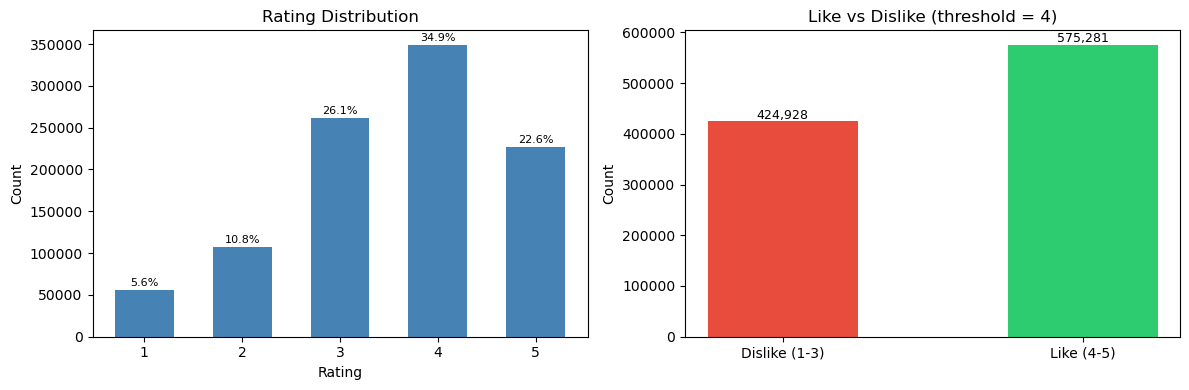

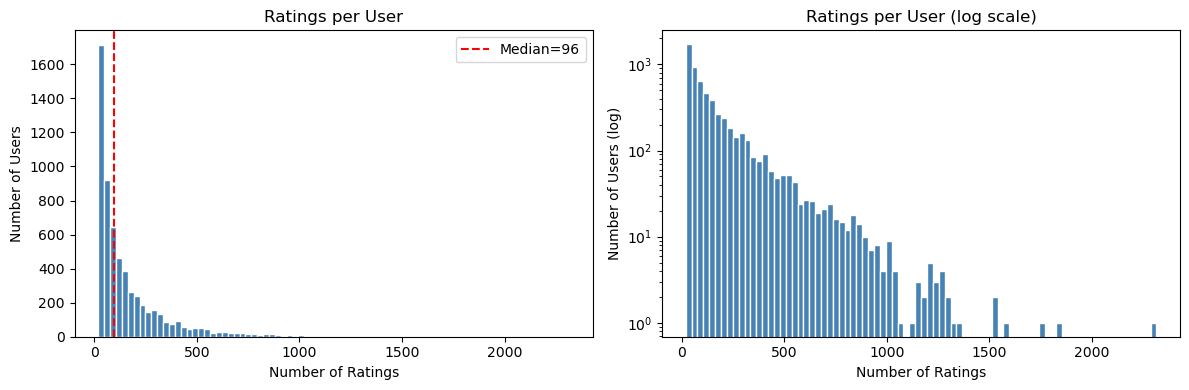

  P10: 27
  P25: 44
  P50: 96
  P75: 208
  P90: 400
  P95: 556
  P99: 907


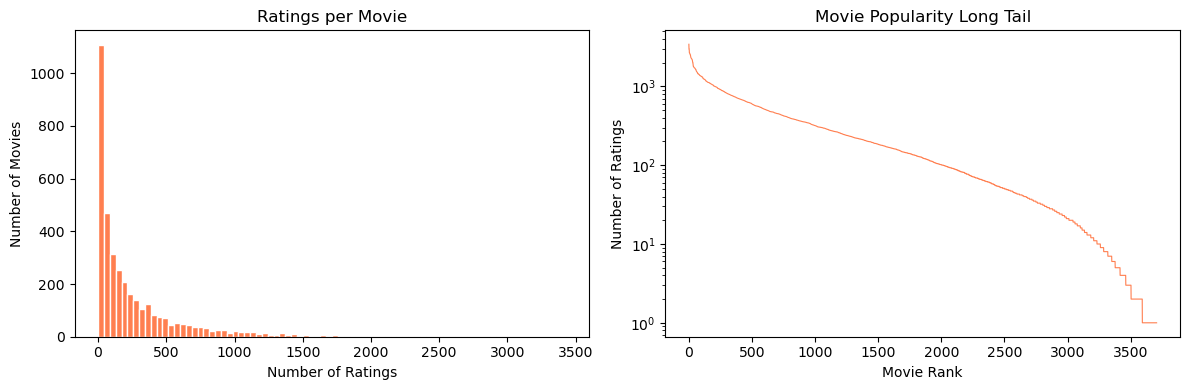

Movies with ≤10 ratings : 473
Movies with ≤50 ratings : 1207

Top 10 most rated:
  American Beauty (1999)                        3,428
  Star Wars: Episode IV - A New Hope (1977)     2,991
  Star Wars: Episode V - The Empire Strikes Back (1980) 2,990
  Star Wars: Episode VI - Return of the Jedi (1983) 2,883
  Jurassic Park (1993)                          2,672
  Saving Private Ryan (1998)                    2,653
  Terminator 2: Judgment Day (1991)             2,649
  Matrix, The (1999)                            2,590
  Back to the Future (1985)                     2,583
  Silence of the Lambs, The (1991)              2,578


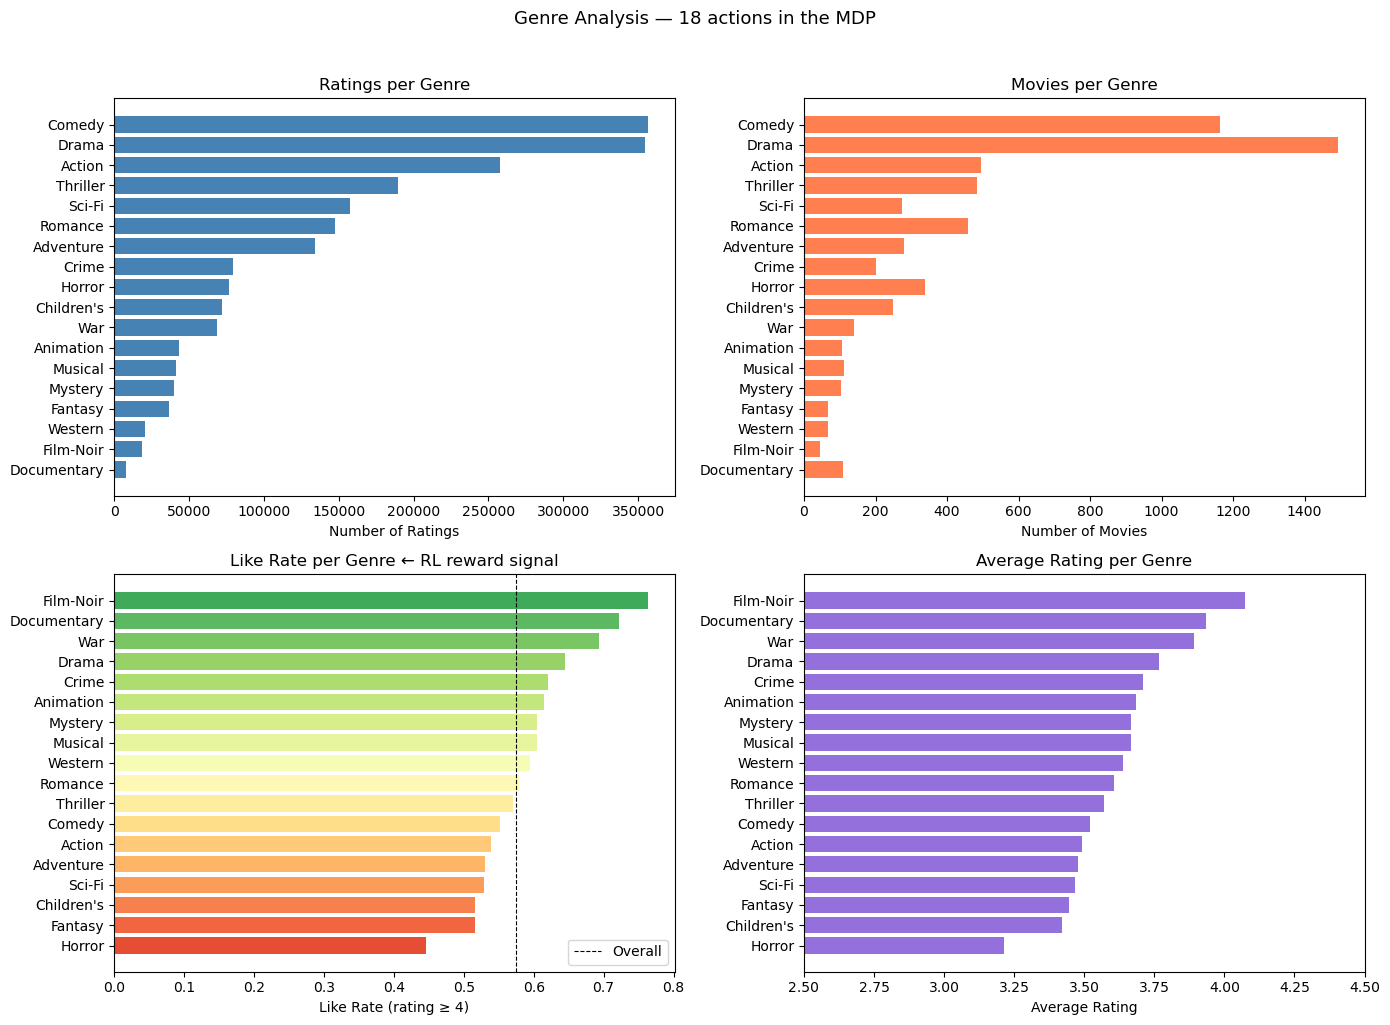

Saved → eda/genre_stats.csv
             n_ratings  n_movies  avg_rating  like_rate
genre                                                  
Comedy          356580      1163       3.522      0.552
Drama           354529      1493       3.766      0.644
Action          257457       495       3.491      0.539
Thriller        189680       485       3.570      0.571
Sci-Fi          157294       274       3.467      0.529
Romance         147523       459       3.607      0.580
Adventure       133953       281       3.477      0.530
Crime            79541       201       3.709      0.620
Horror           76386       339       3.215      0.446
Children's       72186       250       3.422      0.516
War              68527       141       3.893      0.694
Animation        43293       105       3.685      0.615
Musical          41533       113       3.666      0.605
Mystery          40178       104       3.668      0.605
Fantasy          36301        68       3.447      0.516
Western          206

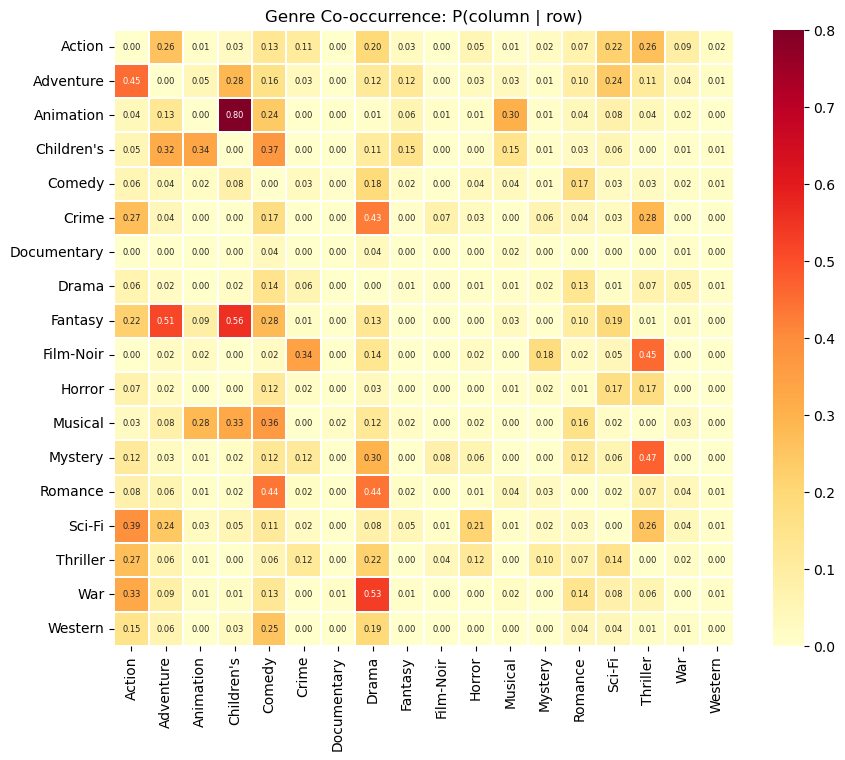

Saved → eda/genre_cooccurrence.npy
Saved → eda/genre_order.csv
Average genres per movie: 1.67


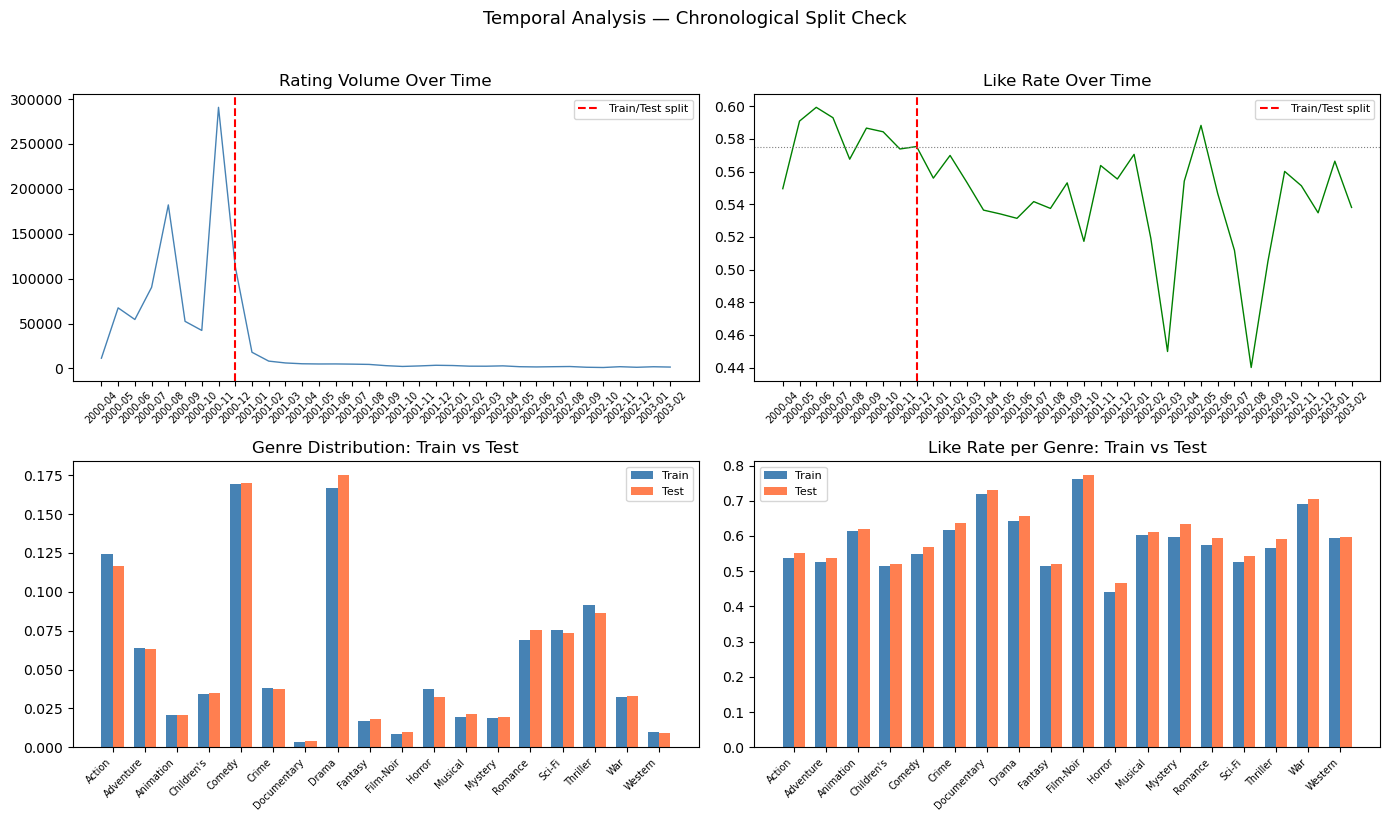

Genre distribution shift (L1): 0.0427
Top shifted genres:
  Drama          : Δ=0.0083
  Action         : Δ=0.0075
  Romance        : Δ=0.0064
  Horror         : Δ=0.0053
  Thriller       : Δ=0.0052


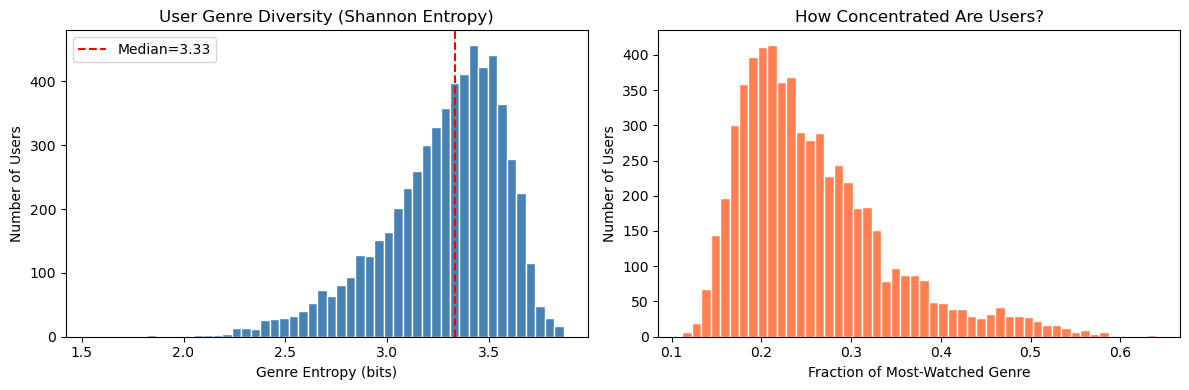

Saved → eda/user_genre_diversity.csv
Entropy  — Mean: 3.27  Median: 3.33  Max possible: 4.17
Dom frac — Mean: 25.79%  Median: 23.79%


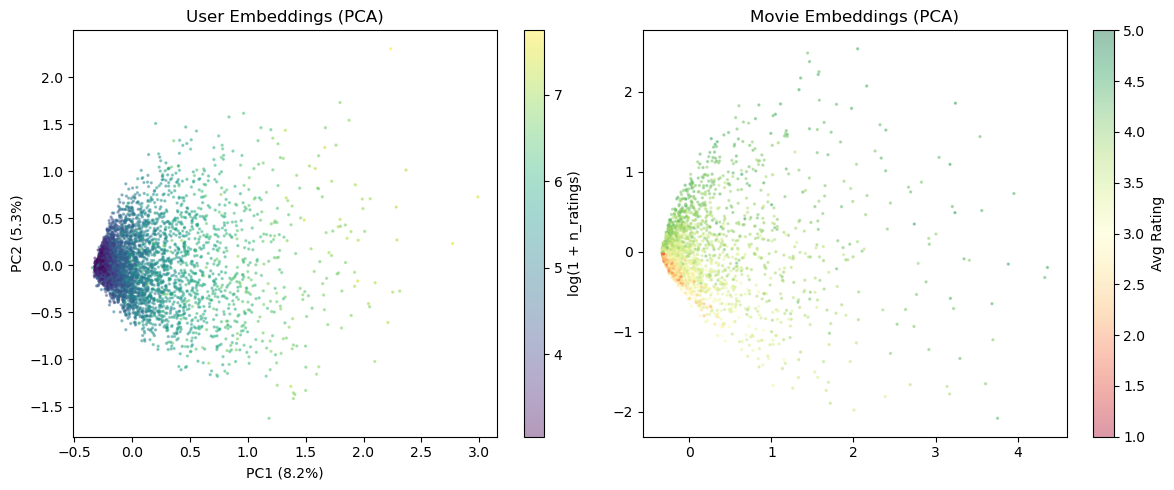

User PCA explained variance: 13.6%
All EDA outputs in 'eda/':

Plots:
  01_rating_distribution.png
  02_user_activity.png
  03_movie_popularity.png
  04_genre_analysis.png
  05_genre_cooccurrence.png
  06_temporal_analysis.png
  07_user_genre_diversity.png
  08_svd_embeddings.png
  09_policy_comparison.png

Derived features:
  genre_cooccurrence.npy
  genre_order.csv
  genre_stats.csv
  user_genre_diversity.csv


In [2]:
# CELL 2: EDA (plots + save derived features)
from eda import run_all_eda

run_all_eda(ctx)

In [3]:
# CELL 3: Unpack ctx + load EDA features
from eda import load_genre_stats, load_genre_cooccurrence, load_user_diversity

# Live objects for RL pipeline
U_embed           = ctx["U_embed"]
M_embed           = ctx["M_embed"]
xgb_model         = ctx["xgb_model"]
user2idx          = ctx["user2idx"]
movie2idx         = ctx["movie2idx"]
genre_to_movies   = ctx["genre_to_movies"]
movie_genres      = ctx["movie_genres"]
get_p_like        = ctx["helpers"]["get_p_like"]
get_movie_genres  = ctx["helpers"]["get_movie_genres"]
count_same_genres = ctx["helpers"]["count_same_genres"]

# Saved EDA features (for reward design, evaluation)
genre_stats            = load_genre_stats()
cooccur, genre_order   = load_genre_cooccurrence()
user_div               = load_user_diversity()

print(f"Loaded {len(user2idx):,} users, {len(movie2idx):,} movies")
print(f"Genre stats shape: {genre_stats.shape}")
print(f"Co-occurrence shape: {cooccur.shape}")
print(f"User diversity shape: {user_div.shape}")

Loaded 6,040 users, 3,706 movies
Genre stats shape: (18, 4)
Co-occurrence shape: (18, 18)
User diversity shape: (6040, 3)


In [4]:
# CELL 4: Load GRU4Rec simulator
from gru4rec import train_gru4rec, make_gru4rec_p_like

gru4rec_model  = train_gru4rec(ctx, save_dir="outputs/simulators", n_epochs=50)
gru4rec_p_like = make_gru4rec_p_like(gru4rec_model, movie2idx, T=20)

# Quick sanity check
sample_user  = list(user2idx.keys())[0]
sample_movie = list(movie2idx.keys())[0]
p = gru4rec_p_like(sample_user, sample_movie, episode_sequence=[])
print(f"Sanity check — P(like | user={sample_user}, movie={sample_movie}): {p:.3f}")

[gru4rec] Device: cpu
[gru4rec] Building sequence datasets ...
[gru4rec] Train sequences: 232,826  Test sequences: 64,344
[gru4rec] Training (50 epochs, patience=8, dropout=0.3, wd=0.0001) ...
  Epoch  1/50  loss=0.6618  AUC=0.6307  lr=5.0e-04
  Epoch  2/50  loss=0.6430  AUC=0.6552  lr=5.0e-04
  Epoch  3/50  loss=0.6349  AUC=0.6701  lr=5.0e-04
  Epoch  4/50  loss=0.6288  AUC=0.6772  lr=5.0e-04
  Epoch  5/50  loss=0.6234  AUC=0.6867  lr=5.0e-04
  Epoch  6/50  loss=0.6176  AUC=0.6957  lr=5.0e-04
  Epoch  7/50  loss=0.6119  AUC=0.7039  lr=5.0e-04
  Epoch  8/50  loss=0.6067  AUC=0.7104  lr=5.0e-04
  Epoch  9/50  loss=0.6018  AUC=0.7156  lr=5.0e-04
  Epoch 10/50  loss=0.5965  AUC=0.7189  lr=5.0e-04
  Epoch 11/50  loss=0.5925  AUC=0.7208  lr=5.0e-04
  Epoch 12/50  loss=0.5885  AUC=0.7233  lr=5.0e-04
  Epoch 13/50  loss=0.5848  AUC=0.7230  lr=5.0e-04
  Epoch 14/50  loss=0.5814  AUC=0.7202  lr=5.0e-04
  Epoch 15/50  loss=0.5788  AUC=0.7168  lr=5.0e-04
  Epoch 16/50  loss=0.5766  AUC=0.7187  lr

In [5]:
# CELL 5: Create environment
from env import FinalMovieRecEnvV6

env = FinalMovieRecEnvV6(ctx, gru4rec_p_like=gru4rec_p_like, T=20, window=10)

# Quick manual test
obs, info = env.reset()
print(f"Env ready — state shape: {obs.shape}, T={env.T}, window={env.window}")

for i in range(3):
    action = env.action_space.sample()
    obs, reward, done, _, info = env.step(action)
    print(f"  Step {i+1}: genre={info['genre']}, p_like={info['p_like']:.3f}, reward={reward}")
print("Manual test OK")

Env ready — state shape: (68,), T=20, window=10
  Step 1: genre=Horror, p_like=0.519, reward=0.0
  Step 2: genre=Crime, p_like=0.763, reward=1.0
  Step 3: genre=Documentary, p_like=0.540, reward=1.0
Manual test OK


In [6]:
# CELL 6: Train DQN
from stable_baselines3 import DQN
from baselines import EpisodeRewardCallback

callback_dqn = EpisodeRewardCallback()

model_dqn = DQN(
    policy        = "MlpPolicy",
    env           = env,
    policy_kwargs = dict(net_arch=[128, 128]),
    learning_rate          = 3e-4,
    gamma                  = 0.99,
    buffer_size            = 30_000,
    learning_starts        = 1000,
    batch_size             = 128,
    exploration_fraction   = 0.4,
    exploration_final_eps  = 0.05,
    train_freq             = 4,
    target_update_interval = 500,
    verbose                = 0,
    device                 = "cpu",
)

print("Training DQN (120k timesteps) ...")
model_dqn.learn(total_timesteps=120_000, callback=callback_dqn, progress_bar=True)
print(f"Done — {len(callback_dqn.episode_rewards)} episodes")

Output()

Training DQN (120k timesteps) ...


Done — 6000 episodes


In [7]:
# CELL 7: Train PPO
from stable_baselines3 import PPO

callback_ppo = EpisodeRewardCallback()

model_ppo = PPO(
    policy        = "MlpPolicy",
    env           = env,
    policy_kwargs = dict(net_arch=[128, 128]),
    learning_rate = 3e-4,
    gamma         = 0.99,
    n_steps       = 2048,
    batch_size    = 128,
    n_epochs      = 10,
    verbose       = 0,
    device        = "cpu",
)

print("Training PPO (120k timesteps) ...")
model_ppo.learn(total_timesteps=120_000, callback=callback_ppo, progress_bar=True)
print(f"Done — {len(callback_ppo.episode_rewards)} episodes")

Output()

Training PPO (120k timesteps) ...


Done — 6041 episodes


[eval] Running Bernoulli evaluation (500 episodes) ...
  random    : 10.21 ± 2.46
  greedy    : 11.50 ± 2.78
  dqn       : 11.21 ± 2.73
  ppo       : 12.78 ± 2.42

FINAL COMPARISON — BERNOULLI REWARD  (T=20, n=500)
Policy                  Mean     Std
----------------------------------------
Random                10.206 ± 2.462
Greedy-CTR            11.496 ± 2.784
DQN                   11.214 ± 2.726
PPO                   12.784 ± 2.424

DQN vs Random     : +1.008
DQN vs Greedy-CTR : -0.282  ← key metric
PPO vs Random     : +2.578
PPO vs Greedy-CTR : +1.288  ← key metric
[eval] Running expected-reward evaluation (200 episodes) ...
  random    : 10.115 ± 1.239
  greedy    : 11.388 ± 1.949
  dqn       : 11.106 ± 1.762
  ppo       : 12.897 ± 1.335

FINAL COMPARISON — EXPECTED REWARD  (T=20, n=200)
Policy                  Mean     Std
----------------------------------------
Random                10.115 ± 1.239
Greedy-CTR            11.388 ± 1.949
DQN                   11.106 ± 1.762
PPO  

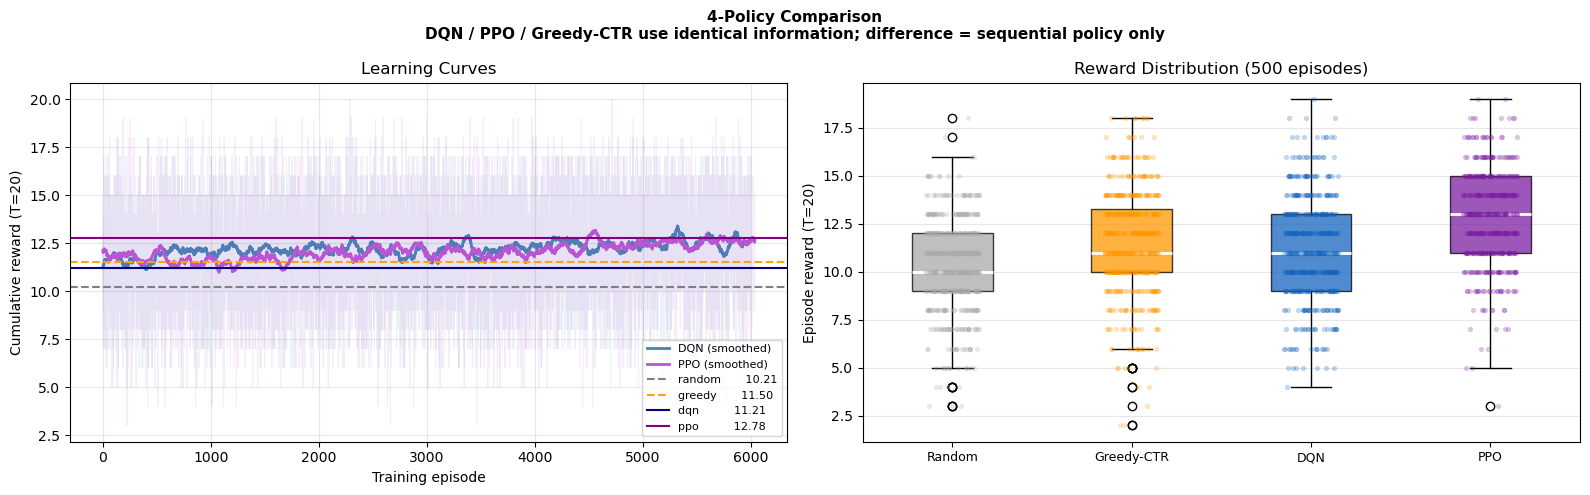

In [8]:
# CELL 8: Evaluate all policies
from evaluate import (
    run_full_evaluation, run_expected_evaluation,
    print_results_table, plot_comparison, run_ttest,
)

# Bernoulli reward evaluation
results = run_full_evaluation(env, model_dqn, model_ppo, n_eval=500, seed=42)
print_results_table(results, label="BERNOULLI REWARD")

# Expected reward evaluation (no sampling noise)
results_exp = run_expected_evaluation(env, model_dqn, model_ppo, n_eval=200)
print_results_table(results_exp, label="EXPECTED REWARD")

# Statistical significance
run_ttest(results, "dqn", "greedy")
run_ttest(results, "ppo", "greedy")

# Plots
plot_comparison(
    results,
    callback_dqn=callback_dqn,
    callback_ppo=callback_ppo,
    T=env.T,
    save_path="eda/09_policy_comparison.png",
)

In [9]:
# CELL 9: Ablation study (state without genre counts)
from env import EnvNoGenreCounts

env_ablation = EnvNoGenreCounts(ctx, gru4rec_p_like=gru4rec_p_like, T=20, window=10)
print(f"Ablation env — state shape: {env_ablation.observation_space.shape}")

# Train ablation DQN
callback_dqn_abl = EpisodeRewardCallback()
model_dqn_ablation = DQN(
    policy="MlpPolicy", env=env_ablation,
    policy_kwargs=dict(net_arch=[128, 128]),
    learning_rate=3e-4, gamma=0.99,
    buffer_size=30_000, learning_starts=1000,
    batch_size=128, exploration_fraction=0.4,
    exploration_final_eps=0.05, train_freq=4,
    target_update_interval=500, verbose=0, device="cpu",
)
print("Training DQN ablation (120k timesteps) ...")
model_dqn_ablation.learn(total_timesteps=120_000, callback=callback_dqn_abl,
                          progress_bar=True)

# Train ablation PPO
callback_ppo_abl = EpisodeRewardCallback()
model_ppo_ablation = PPO(
    policy="MlpPolicy", env=env_ablation,
    policy_kwargs=dict(net_arch=[128, 128]),
    learning_rate=3e-4, gamma=0.99,
    n_steps=2048, batch_size=128, n_epochs=10,
    verbose=0, device="cpu",
)
print("Training PPO ablation (120k timesteps) ...")
model_ppo_ablation.learn(total_timesteps=120_000, callback=callback_ppo_abl,
                          progress_bar=True)

# Evaluate ablation models on same users
from evaluate import run_ablation_eval

eval_users = results["eval_users"]

dqn_abl_rewards = run_ablation_eval(env_ablation, model_dqn_ablation, eval_users, "DQN")
ppo_abl_rewards = run_ablation_eval(env_ablation, model_ppo_ablation, eval_users, "PPO")

import numpy as np
print(f"\nDQN (full state): {np.mean(results['dqn']):.2f} ± {np.std(results['dqn']):.2f}")
print(f"DQN (no genre) : {np.mean(dqn_abl_rewards):.2f} ± {np.std(dqn_abl_rewards):.2f}")
print(f"PPO (full state): {np.mean(results['ppo']):.2f} ± {np.std(results['ppo']):.2f}")
print(f"PPO (no genre) : {np.mean(ppo_abl_rewards):.2f} ± {np.std(ppo_abl_rewards):.2f}")

Output()

Ablation env — state shape: (50,)
Training DQN ablation (120k timesteps) ...


Output()

Training PPO ablation (120k timesteps) ...


[ablation] DQN (no genre counts): 11.96 ± 2.72
[ablation] PPO (no genre counts): 12.76 ± 2.63

DQN (full state): 11.21 ± 2.73
DQN (no genre) : 11.96 ± 2.72
PPO (full state): 12.78 ± 2.42
PPO (no genre) : 12.76 ± 2.63


In [ ]:
# CELL 10: GRU4Rec fatigue evaluation
from gru4rec import probe_fatigue_curve, paired_fatigue_probe

print("Probing GRU4Rec fatigue signal ...")
fatigue_df = probe_fatigue_curve(env, ctx, n_users=30, n_targets_per_user=5, hist_len=4)

fatigue_summary = (
    fatigue_df.groupby("k_same_genre")["p_like"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
print("\nFatigue curve (P(like) by same-genre repetitions):")
print(fatigue_summary.to_string(index=False))

print("\nPaired fatigue probe ...")
paired_df = paired_fatigue_probe(env, ctx, n_pairs=200, hist_len=4)
print(f"Mean delta (mixed - same): {paired_df['delta_mix_minus_same'].mean():.4f}")
print(paired_df["delta_mix_minus_same"].describe())

Probing GRU4Rec fatigue signal ...

Fatigue curve (P(like) by same-genre repetitions):
 k_same_genre     mean      std  count
            0 0.510395 0.147912    150
            1 0.512075 0.151526    150
            2 0.514219 0.143268    150
            3 0.503734 0.148487    150
            4 0.508446 0.152064    150

Paired fatigue probe ...
Mean delta (mixed - same): -0.0007
count    200.000000
mean      -0.000723
std        0.061535
min       -0.158149
25%       -0.037405
50%       -0.000594
75%        0.035297
max        0.167301
Name: delta_mix_minus_same, dtype: float64


In [11]:
# CELL 11: Save all artifacts
from evaluate import save_all_artifacts

save_all_artifacts(
    output_dir          = "outputs",
    model_dqn           = model_dqn,
    model_ppo           = model_ppo,
    gru4rec_model       = gru4rec_model,
    xgb_model           = xgb_model,
    U_embed             = U_embed,
    M_embed             = M_embed,
    model_dqn_ablation  = model_dqn_ablation,
    model_ppo_ablation  = model_ppo_ablation,
)


[save] All artifacts saved to 'outputs/':
outputs/
  embeddings/
    M_embed.npy                    0.71 MB
    U_embed.npy                    1.15 MB
  simulators/
    gru4rec_best.pt                1.02 MB
    xgb_simulator.json             0.92 MB
  agents/
    dqn_ablation_v8.zip            0.41 MB
    dqn_v8.zip                     0.45 MB
    ppo_ablation_v8.zip            0.59 MB
    ppo_v8.zip                     0.64 MB


In [12]:
# Track genre selections over 500 eval episodes
from collections import Counter
genre_counts_dqn = Counter()
for user in results["eval_users"]:
    obs, _ = env.reset(options={"user_id": user})
    done = False
    while not done:
        action, _ = model_dqn.predict(obs, deterministic=True)
        genre_counts_dqn[env.all_genres[int(action)]] += 1
        obs, _, done, _, _ = env.step(action)

for g, c in genre_counts_dqn.most_common():
    print(f"  {g:<15s}: {c:5d}  ({c/sum(genre_counts_dqn.values()):.1%})")

  Comedy         :  8024  (80.2%)
  Film-Noir      :   581  (5.8%)
  War            :   358  (3.6%)
  Musical        :   245  (2.5%)
  Documentary    :   243  (2.4%)
  Western        :   240  (2.4%)
  Crime          :   233  (2.3%)
  Animation      :    76  (0.8%)
